# 🪨 LITHOS — Phase 3: Deep Learning (CNN + LSTM + InSAR)
### Landslide Intelligence using Temporal & Hyperlocal Observation System

---
**What Phase 3 adds over Phase 2:**

| Component | What it learns | Why it matters |
|---|---|---|
| 🖼️ CNN | Spatial patterns in satellite image patches | Sees terrain shape, not just numbers |
| 📈 LSTM | Temporal rainfall sequences (72h window) | Learns HOW rain builds up before slides |
| 🌍 InSAR | Millimeter ground deformation from Sentinel-1 | Detects slope creep BEFORE collapse |
| 🔀 Fusion | CNN + LSTM + tabular combined | Best of all three signal types |

---
> ⚠️ **Before running:**
> - Google Drive must have `LITHOS/Phase1_data` from Phase 1
> - Add `COPERNICUS_PASS` to 🔑 Colab Secrets
> - Enable GPU: Runtime → Change runtime type → T4 GPU
> - Then: **Runtime → Run All**

## 📦 Step 1 — Install Libraries

In [23]:
!pip install requests geopandas rasterio numpy pandas matplotlib folium \
             shapely scipy scikit-learn xgboost imbalanced-learn shap \
             openmeteo-requests requests-cache retry-requests tqdm torch \
             torchvision -q
!apt-get install -y gdal-bin -q

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Libraries installed!')
print(f'   Device: {device} ({"GPU available!" if device=="cuda" else "CPU only — GPU recommended"})')

Reading package lists...
Building dependency tree...
Reading state information...
gdal-bin is already the newest version (3.8.4+dfsg-1~jammy0).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
✅ Libraries installed!
   Device: cuda (GPU available!)


In [24]:
import os, glob

print("=" * 55)
print("🔍 LITHOS — Real Data File Checker")
print("=" * 55)

def check(label, paths):
    found = False
    for p in paths:
        matches = glob.glob(p, recursive=True)
        if matches:
            for m in matches:
                size = os.path.getsize(m) / 1024 / 1024
                print(f"  ✅ {label}: {m} ({size:.1f} MB)")
            found = True
    if not found:
        print(f"  ❌ {label}: NOT FOUND — {paths[0]}")
    return found

print("\n📡 SENTINEL-2 (CNN Patches)")
check("S2 zip",        ["lithos_data/sentinel2/*.zip"])
check("S2 B02 band",   ["lithos_data/sentinel2/**/*B02*.jp2"])
check("S2 B03 band",   ["lithos_data/sentinel2/**/*B03*.jp2"])
check("S2 B04 band",   ["lithos_data/sentinel2/**/*B04*.jp2"])
check("S2 B08 band",   ["lithos_data/sentinel2/**/*B08*.jp2"])

print("\n📡 SENTINEL-1 (InSAR)")
check("S1 pre-event",  ["lithos_data/sentinel1/pre_event/*.zip"])
check("S1 post-event", ["lithos_data/sentinel1/post_event/*.zip"])

print("\n🏔️  DEM / TERRAIN")
check("SRTM DEM",      ["lithos_data/dem/cherrapunji_dem.tif"])

print("\n🌧️  WEATHER")
check("Weather CSV",   ["lithos_data/weather/cherrapunji_weather*.csv"])

print("\n🌍 NASA LANDSLIDES")
check("NASA CSV",      ["lithos_data/landslides/nasa_raw.csv",
                        "nasa_landslides.csv",
                        "Global_Landslide_Catalog.csv"])

print("\n🗺️  GRID FILES")
check("Phase 2 grid",  ["lithos_data/phase2/lithos_phase2_grid.gpkg"])
check("Phase 1 grid",  ["lithos_data/lithos_feature_grid.gpkg"])

print("\n🛣️  ROAD NETWORKS")
check("Cherrapunji",   ["lithos_data/roads/cherrapunji.gpkg"])
check("Wayanad",       ["lithos_data/roads/wayanad.gpkg"])

print("\n" + "=" * 55)
print("💡 Any ❌ = that step will use SYNTHETIC fallback")
print("   Fix: re-run Phase 1 or check Drive copy path")
print("=" * 55)

🔍 LITHOS — Real Data File Checker

📡 SENTINEL-2 (CNN Patches)
  ✅ S2 zip: lithos_data/sentinel2/S2A_MSIL1C_20221129T042131_N0510_R090_T46RDP_20240730T152504.SAFE.zip (615.7 MB)
  ✅ S2 zip: lithos_data/sentinel2/S2B_MSIL1C_20220428T041539_N0510_R090_T46RDN_20240606T102028.SAFE.zip (650.6 MB)
  ✅ S2 zip: lithos_data/sentinel2/S2B_MSIL1C_20220819T042709_N0510_R133_T46RCP_20240718T115954.SAFE.zip (792.3 MB)
  ❌ S2 B02 band: NOT FOUND — lithos_data/sentinel2/**/*B02*.jp2
  ❌ S2 B03 band: NOT FOUND — lithos_data/sentinel2/**/*B03*.jp2
  ❌ S2 B04 band: NOT FOUND — lithos_data/sentinel2/**/*B04*.jp2
  ❌ S2 B08 band: NOT FOUND — lithos_data/sentinel2/**/*B08*.jp2

📡 SENTINEL-1 (InSAR)
  ✅ S1 pre-event: lithos_data/sentinel1/pre_event/S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE.zip (1646.5 MB)
  ✅ S1 post-event: lithos_data/sentinel1/post_event/S1A_IW_GRDH_1SDV_20220628T115711_20220628T115736_043863_053C7E_C351.SAFE.zip (1658.2 MB)

🏔️  DEM / TERRAIN
  ✅ SRTM DEM: li

In [25]:
import shutil, os, glob

print("🔧 Fixing missing Sentinel-2 files...")
print("=" * 55)

# ── Step 1: Find S2 zips in Drive ──
drive_s2_pattern = "/content/drive/MyDrive/LITHOS/Phase1_data/sentinel2/*.zip"
drive_s2_files   = glob.glob(drive_s2_pattern)

if drive_s2_files:
    os.makedirs("lithos_data/sentinel2", exist_ok=True)
    for src in drive_s2_files:
        fname = os.path.basename(src)
        dst   = f"lithos_data/sentinel2/{fname}"
        if os.path.exists(dst):
            print(f"  ⏭️  Already exists: {fname[:60]}")
        else:
            size_gb = os.path.getsize(src) / 1024 / 1024 / 1024
            print(f"  📦 Copying {fname[:55]} ({size_gb:.1f} GB)...")
            shutil.copy2(src, dst)
            print(f"  ✅ Done!")
else:
    print("  ❌ No S2 zips found in Drive at:")
    print(f"     {drive_s2_pattern}")

# ── Step 2: Fix NASA CSV ──
print("\n🌍 Fixing NASA Landslide CSV...")
nasa_candidates = [
    "/content/drive/MyDrive/LITHOS/Phase1_data/landslides/nasa_raw.csv",
    "/content/drive/MyDrive/LITHOS/Phase1_data/cherrapunji_landslides.csv",
    "/content/drive/MyDrive/LITHOS/Phase1_data/northeast_india_landslides.csv",
    "/content/drive/MyDrive/LITHOS/Phase1_data/kerala_landslides.csv",
]

os.makedirs("lithos_data/landslides", exist_ok=True)
for src in nasa_candidates:
    if os.path.exists(src):
        fname = os.path.basename(src)
        dst   = f"lithos_data/landslides/{fname}"
        shutil.copy2(src, dst)
        print(f"  ✅ Copied: {fname}")

# ── Step 3: Re-run checker ──
print("\n📋 Re-checking files...")
print("=" * 55)

checks = {
    "S2 zips":        "lithos_data/sentinel2/*.zip",
    "NASA CSV":       "lithos_data/landslides/*.csv",
    "S1 pre-event":   "lithos_data/sentinel1/pre_event/*.zip",
    "S1 post-event":  "lithos_data/sentinel1/post_event/*.zip",
    "DEM":            "lithos_data/dem/*.tif",
    "Weather CSV":    "lithos_data/weather/*.csv",
    "Phase 2 grid":   "lithos_data/phase2/*.gpkg",
}

all_good = True
for label, pattern in checks.items():
    matches = glob.glob(pattern)
    if matches:
        for m in matches:
            size = os.path.getsize(m) / 1024 / 1024
            print(f"  ✅ {label}: {os.path.basename(m)} ({size:.1f} MB)")
    else:
        print(f"  ❌ {label}: MISSING")
        all_good = False

print("=" * 55)
if all_good:
    print("🎉 All files present — CNN will use REAL Sentinel-2 data!")
else:
    print("⚠️  Some files still missing — those steps will use synthetic fallback")

🔧 Fixing missing Sentinel-2 files...
  ❌ No S2 zips found in Drive at:
     /content/drive/MyDrive/LITHOS/Phase1_data/sentinel2/*.zip

🌍 Fixing NASA Landslide CSV...

📋 Re-checking files...
  ✅ S2 zips: S2A_MSIL1C_20221129T042131_N0510_R090_T46RDP_20240730T152504.SAFE.zip (615.7 MB)
  ✅ S2 zips: S2B_MSIL1C_20220428T041539_N0510_R090_T46RDN_20240606T102028.SAFE.zip (650.6 MB)
  ✅ S2 zips: S2B_MSIL1C_20220819T042709_N0510_R133_T46RCP_20240718T115954.SAFE.zip (792.3 MB)
  ✅ NASA CSV: cherrapunji_landslides.csv (0.0 MB)
  ✅ NASA CSV: northeast_india_landslides.csv (0.5 MB)
  ✅ NASA CSV: kerala_landslides.csv (0.1 MB)
  ✅ S1 pre-event: S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE.zip (1646.5 MB)
  ✅ S1 post-event: S1A_IW_GRDH_1SDV_20220628T115711_20220628T115736_043863_053C7E_C351.SAFE.zip (1658.2 MB)
  ✅ DEM: cherrapunji_dem.tif (0.6 MB)
  ✅ Weather CSV: cherrapunji_weather_2018_2023.csv (4.8 MB)
  ✅ Phase 2 grid: lithos_phase2_grid.gpkg (0.8 MB)
🎉 All files pre

In [26]:
import os, glob

print("🔍 Searching entire Drive for Sentinel-2 zips...")
print("(This may take 30 seconds)\n")

# Search all possible locations
found = []
search_roots = [
    "/content/drive/MyDrive/LITHOS",
    "/content/drive/MyDrive",
]

for root in search_roots:
    if os.path.exists(root):
        for dirpath, dirnames, filenames in os.walk(root):
            for fname in filenames:
                if fname.endswith(".zip") and "S2" in fname:
                    full = os.path.join(dirpath, fname)
                    size = os.path.getsize(full) / 1024 / 1024 / 1024
                    found.append(full)
                    print(f"  ✅ FOUND: {full}")
                    print(f"     Size: {size:.1f} GB")

print(f"\n📊 Total S2 zips found: {len(found)}")
if not found:
    print("\n❌ No S2 zips anywhere in Drive.")
    print("   They were likely never saved from Phase 1.")
    print("\n💡 Fix options:")
    print("   1. Re-run Phase 1 Step 5 (download Sentinel-2)")
    print("      then Step 12 (save to Drive)")
    print("   2. Or manually download from:")
    print("      https://dataspace.copernicus.eu")

🔍 Searching entire Drive for Sentinel-2 zips...
(This may take 30 seconds)

  ✅ FOUND: /content/drive/MyDrive/LITHOS/Phase2_data/sentinel2_pre_monsoon/S2B_MSIL1C_20220428T041539_N0510_R090_T46RDN_20240606T102028.SAFE.zip
     Size: 0.6 GB
  ✅ FOUND: /content/drive/MyDrive/LITHOS/Phase2_data/sentinel2_peak_monsoon/S2B_MSIL1C_20220819T042709_N0510_R133_T46RCP_20240718T115954.SAFE.zip
     Size: 0.8 GB
  ✅ FOUND: /content/drive/MyDrive/LITHOS/Phase2_data/sentinel2_post_monsoon/S2A_MSIL1C_20221129T042131_N0510_R090_T46RDP_20240730T152504.SAFE.zip
     Size: 0.6 GB
  ✅ FOUND: /content/drive/MyDrive/LITHOS/Phase1_data_v01/sentinel2/S2A_MSIL1C_20220910T041601_N0510_R090_T46RDP_20240728T083610.SAFE.zip
     Size: 0.6 GB
  ✅ FOUND: /content/drive/MyDrive/LITHOS/Phase2_data/sentinel2_pre_monsoon/S2B_MSIL1C_20220428T041539_N0510_R090_T46RDN_20240606T102028.SAFE.zip
     Size: 0.6 GB
  ✅ FOUND: /content/drive/MyDrive/LITHOS/Phase2_data/sentinel2_peak_monsoon/S2B_MSIL1C_20220819T042709_N0510_R133_T

In [27]:
import shutil, os, glob

print("📦 Copying Sentinel-2 zips from Phase2_data...")
print("=" * 55)

os.makedirs("lithos_data/sentinel2", exist_ok=True)

# ✅ Use only Phase 2 seasonal zips — best coverage, skip old Phase1_data_v01
s2_sources = [
    "/content/drive/MyDrive/LITHOS/Phase2_data/sentinel2_pre_monsoon/S2B_MSIL1C_20220428T041539_N0510_R090_T46RDN_20240606T102028.SAFE.zip",
    "/content/drive/MyDrive/LITHOS/Phase2_data/sentinel2_peak_monsoon/S2B_MSIL1C_20220819T042709_N0510_R133_T46RCP_20240718T115954.SAFE.zip",
    "/content/drive/MyDrive/LITHOS/Phase2_data/sentinel2_post_monsoon/S2A_MSIL1C_20221129T042131_N0510_R090_T46RDP_20240730T152504.SAFE.zip",
]

for src in s2_sources:
    fname  = os.path.basename(src)
    dst    = f"lithos_data/sentinel2/{fname}"
    season = "pre" if "pre" in src else "peak" if "peak" in src else "post"
    if os.path.exists(dst):
        print(f"  ⏭️  Already exists: {season}-monsoon")
        continue
    size_gb = os.path.getsize(src) / 1024**3
    print(f"  📦 Copying {season}-monsoon ({size_gb:.1f} GB)... please wait...")
    shutil.copy2(src, dst)
    print(f"  ✅ {season}-monsoon done!")

print("\n✅ All 3 seasonal zips ready — CNN will use real Sentinel-2 data")
print("⚠️  Phase1_data_v01 ignored — not needed, Phase2_data is better")
print("=" * 55)

📦 Copying Sentinel-2 zips from Phase2_data...
  ⏭️  Already exists: pre-monsoon
  ⏭️  Already exists: peak-monsoon
  ⏭️  Already exists: post-monsoon

✅ All 3 seasonal zips ready — CNN will use real Sentinel-2 data
⚠️  Phase1_data_v01 ignored — not needed, Phase2_data is better


## 💾 Step 2 — Mount Drive + Load Phase 1 Data

In [28]:
from google.colab import drive, userdata
import os, shutil

drive.mount('/content/drive')

# ── Load Phase 1 data ──
DRIVE_P1 = '/content/drive/MyDrive/LITHOS/Phase1_data'
DRIVE_P2 = '/content/drive/MyDrive/LITHOS/Phase2_data'

if os.path.exists(DRIVE_P1):
    shutil.copytree(DRIVE_P1, 'lithos_data', dirs_exist_ok=True)
    print(f'✅ Phase 1 data loaded!')
else:
    print(f'❌ Phase 1 data not found at {DRIVE_P1}')
    print('   Make sure you ran Phase 1 and saved to Drive')

# Load Phase 2 grid if available
if os.path.exists(DRIVE_P2):
    shutil.copytree(DRIVE_P2, 'lithos_data/phase2', dirs_exist_ok=True)
    print(f'✅ Phase 2 data loaded!')
else:
    print('⚠️  Phase 2 data not found — will use Phase 1 grid only')

print('\n📁 Available files:')
for root, dirs, files in os.walk('lithos_data'):
    level = root.replace('lithos_data', '').count(os.sep)
    if level > 2: continue  # Don't print too deep
    for f in files:
        size = os.path.getsize(os.path.join(root, f))
        print(f'  {"  "*level}{f} ({size//1024}KB)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Phase 1 data loaded!
✅ Phase 2 data loaded!

📁 Available files:
  lithos_phase3_map.html (2032KB)
  lithos_cnn_model.pt (6531KB)
  lithos_interactive_map.html (1956KB)
  lithos_risk_map_phase1.png (93KB)
  lithos_feature_grid.gpkg (584KB)
  lithos_fusion_model.pt (4767KB)
  lithos_lstm_model.pt (866KB)
  lithos_phase3_comparison.png (90KB)
  lithos_phase3_grid.gpkg (896KB)
    munnar.gpkg (728KB)
    arunachal_w.gpkg (3776KB)
    nagaland.gpkg (9920KB)
    idukki.gpkg (3956KB)
    manipur_nh2.gpkg (4228KB)
    sikkim.gpkg (3704KB)
    cherrapunji.gpkg (2716KB)
    wayanad.gpkg (3564KB)
    lithos_phase2_map.html (2045KB)
    lithos_phase2_comparison.png (68KB)
    lithos_shap_beeswarm.png (195KB)
    lithos_shap_importance.png (104KB)
    lithos_phase2_grid.gpkg (816KB)
      S2B_MSIL1C_20220428T041539_N0510_R090_T46RDN_20240606T102028.SAFE.zip (666222KB)
 

## 🔐 Step 3 — Copernicus Authentication

In [29]:
import requests

COPERNICUS_USER = 'sougatakarmakar151@gmail.com'
COPERNICUS_PASS = userdata.get('COPERNICUS_PASS')

def get_token():
    r = requests.post(
        'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token',
        data={'grant_type':'password','client_id':'cdse-public',
              'username':COPERNICUS_USER,'password':COPERNICUS_PASS},
        timeout=30
    )
    return r.json()['access_token'] if r.status_code == 200 else None

TOKEN = get_token()
print(f'✅ Authenticated!' if TOKEN else '❌ Auth failed — check COPERNICUS_PASS in Secrets')

BBOX = (91.4, 25.0, 92.2, 25.6)  # Cherrapunji
print(f'📍 Active region: Cherrapunji, Meghalaya')
print(f'   BBOX: {BBOX}')

✅ Authenticated!
📍 Active region: Cherrapunji, Meghalaya
   BBOX: (91.4, 25.0, 92.2, 25.6)


## 🌍 Step 4 — Download Sentinel-1 for InSAR Ground Deformation

In [30]:
import os
from tqdm import tqdm

os.makedirs('lithos_data/sentinel1/pre_event',  exist_ok=True)
os.makedirs('lithos_data/sentinel1/post_event', exist_ok=True)

min_lon, min_lat, max_lon, max_lat = BBOX
wkt = (f'POLYGON(({min_lon} {min_lat},{max_lon} {min_lat},'
       f'{max_lon} {max_lat},{min_lon} {max_lat},{min_lon} {min_lat}))')

def search_s1(start, end, n=2):
    r = requests.get(
        'https://catalogue.dataspace.copernicus.eu/odata/v1/Products',
        params={
            '$filter': (
                f"Collection/Name eq 'SENTINEL-1' "
                f"and OData.CSC.Intersects(area=geography'SRID=4326;{wkt}') "
                f"and ContentDate/Start gt {start}T00:00:00.000Z "
                f"and ContentDate/Start lt {end}T00:00:00.000Z "
                f"and Attributes/OData.CSC.StringAttribute/any("
                f"att:att/Name eq 'productType' and "
                f"att/OData.CSC.StringAttribute/Value eq 'GRD')"
            ),
            '$top': n, '$orderby': 'ContentDate/Start desc'
        }, timeout=30
    )
    return r.json().get('value', []) if r.status_code == 200 else []

def download_product(product_id, product_name, save_dir):
    token    = get_token()
    url      = f'https://download.dataspace.copernicus.eu/odata/v1/Products({product_id})/$value'
    filepath = os.path.join(save_dir, f'{product_name}.zip')
    if os.path.exists(filepath):
        print(f'  ⏭️  Already exists: {product_name[:45]}')
        return filepath
    session  = requests.Session()
    session.headers.update({'Authorization': f'Bearer {token}'})
    r = session.get(url, stream=True, timeout=300, allow_redirects=True)
    if r.status_code == 200:
        total = int(r.headers.get('content-length', 0))
        with open(filepath, 'wb') as f, tqdm(
            desc=product_name[:30], total=total, unit='iB', unit_scale=True
        ) as bar:
            for chunk in r.iter_content(8192):
                bar.update(f.write(chunk))
        print(f'  ✅ {product_name[:50]}')
        return filepath
    else:
        print(f'  ❌ Failed ({r.status_code})')
        return None

# InSAR needs 2 images of same path/frame — before and after event
# Pre-event: 1 month before June 2022 landslide
print('🔍 Searching Sentinel-1 pre-event (May 2022)...')
s1_pre  = search_s1('2022-05-01', '2022-05-31')
print(f'   Found: {len(s1_pre)}')
for p in s1_pre:
    print(f'   → {p["Name"][:60]} | {p["ContentDate"]["Start"][:10]}')

print('\n🔍 Searching Sentinel-1 post-event (June 2022)...')
s1_post = search_s1('2022-06-15', '2022-06-30')
print(f'   Found: {len(s1_post)}')
for p in s1_post:
    print(f'   → {p["Name"][:60]} | {p["ContentDate"]["Start"][:10]}')

downloaded_s1 = {'pre': [], 'post': []}

print('\n📥 Downloading Sentinel-1 pre-event...')
for p in s1_pre[:1]:
    path = download_product(p['Id'], p['Name'], 'lithos_data/sentinel1/pre_event')
    if path: downloaded_s1['pre'].append(path)

print('\n📥 Downloading Sentinel-1 post-event...')
for p in s1_post[:1]:
    path = download_product(p['Id'], p['Name'], 'lithos_data/sentinel1/post_event')
    if path: downloaded_s1['post'].append(path)

print(f'\n✅ Sentinel-1 downloads:')
print(f'   Pre-event:  {len(downloaded_s1["pre"])} file(s)')
print(f'   Post-event: {len(downloaded_s1["post"])} file(s)')

🔍 Searching Sentinel-1 pre-event (May 2022)...
   Found: 2
   → S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_0530 | 2022-05-30
   → S1A_IW_GRDH_1SDV_20220530T235534_20220530T235559_043447_0530 | 2022-05-30

🔍 Searching Sentinel-1 post-event (June 2022)...
   Found: 2
   → S1A_IW_GRDH_1SDV_20220628T115711_20220628T115736_043863_053C | 2022-06-28
   → S1A_IW_GRDH_1SDV_20220628T115646_20220628T115711_043863_053C | 2022-06-28

📥 Downloading Sentinel-1 pre-event...
  ⏭️  Already exists: S1A_IW_GRDH_1SDV_20220530T235559_20220530T235

📥 Downloading Sentinel-1 post-event...
  ⏭️  Already exists: S1A_IW_GRDH_1SDV_20220628T115711_20220628T115

✅ Sentinel-1 downloads:
   Pre-event:  1 file(s)
   Post-event: 1 file(s)


In [31]:
import zipfile, glob, os

# Check what's actually inside the zip
s1_pre_files = glob.glob('lithos_data/sentinel1/pre_event/*.zip')
s1_post_files = glob.glob('lithos_data/sentinel1/post_event/*.zip')

print(f'Pre-event zips:  {s1_pre_files}')
print(f'Post-event zips: {s1_post_files}')

# List contents without extracting
if s1_pre_files:
    with zipfile.ZipFile(s1_pre_files[0], 'r') as z:
        files = z.namelist()
        print(f'\nFiles inside pre-event zip ({len(files)} total):')
        for f in files[:20]:  # Show first 20 only
            print(f'  {f}')
        tiff_files = [f for f in files if f.endswith('.tiff') or f.endswith('.tif')]
        print(f'\nTIFF files: {len(tiff_files)}')
        for f in tiff_files:
            print(f'  {f}')

Pre-event zips:  ['lithos_data/sentinel1/pre_event/S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE.zip']
Post-event zips: ['lithos_data/sentinel1/post_event/S1A_IW_GRDH_1SDV_20220628T115711_20220628T115736_043863_053C7E_C351.SAFE.zip']

Files inside pre-event zip (34 total):
  S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE/
  S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE/S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE-report-20220531T092043.pdf
  S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE/annotation/
  S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE/annotation/calibration/
  S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE/annotation/calibration/calibration-s1a-iw-grd-vh-20220530t235559-20220530t235624-043447-053018-002.xml
  S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE/annotatio

In [32]:
import geopandas as gpd
import os

# Load Phase 2 grid (has most features)
if os.path.exists('lithos_data/phase2/lithos_phase2_grid.gpkg'):
    grid_gdf = gpd.read_file('lithos_data/phase2/lithos_phase2_grid.gpkg')
    print(f'✅ Loaded Phase 2 grid: {len(grid_gdf)} cells | {len(grid_gdf.columns)} features')
elif os.path.exists('lithos_data/lithos_feature_grid.gpkg'):
    grid_gdf = gpd.read_file('lithos_data/lithos_feature_grid.gpkg')
    print(f'✅ Loaded Phase 1 grid: {len(grid_gdf)} cells')
else:
    print('❌ No grid found — check lithos_data folder')

BBOX = (91.4, 25.0, 92.2, 25.6)
print(f'📍 BBOX: {BBOX}')
print(grid_gdf[['cell_id','center_lat','center_lon']].head(3))

✅ Loaded Phase 2 grid: 1452 cells | 50 features
📍 BBOX: (91.4, 25.0, 92.2, 25.6)
   cell_id  center_lat  center_lon
0        0      25.009      91.409
1        1      25.009      91.427
2        2      25.009      91.445


## 📡 Step 5 — Compute InSAR Ground Deformation

In [33]:
import numpy as np
import rasterio
import zipfile
import glob
import os
import geopandas as gpd
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('📡 Computing InSAR deformation proxy...')

BBOX    = (91.4, 25.0, 92.2, 25.6)
DEM_PATH = 'lithos_data/dem/cherrapunji_dem.tif'

def extract_s1_fast(zip_path, period, target_pol='vv'):
    """
    Fast Sentinel-1 extraction — reads directly from zip
    without full extraction, uses overview for speed
    """
    extract_dir = f'lithos_data/sentinel1/{period}_extracted'
    os.makedirs(extract_dir, exist_ok=True)

    print(f'  📦 Extracting {period}...')

    # Only extract measurement TIFF files — skip preview, metadata
    with zipfile.ZipFile(zip_path, 'r') as z:
        all_files = z.namelist()
        # Only extract the VV measurement file
        tiff_files = [
            f for f in all_files
            if target_pol in f.lower()
            and ('measurement' in f.lower() or 'tiff' in f.lower())
            and (f.endswith('.tiff') or f.endswith('.tif'))
        ]
        print(f'  Target files: {tiff_files}')

        if not tiff_files:
            # Try extracting all tiffs
            tiff_files = [f for f in all_files
                         if f.endswith('.tiff') or f.endswith('.tif')]
            print(f'  Fallback — all tiffs: {tiff_files}')

        for f in tiff_files[:1]:  # Only extract first match
            z.extract(f, extract_dir)
            extracted_path = os.path.join(extract_dir, f)
            print(f'  ✅ Extracted: {os.path.basename(f)}')
            return extracted_path

    return None


def read_s1_downsampled(tiff_path, downsample=10):
    """
    Read Sentinel-1 TIFF at reduced resolution for speed.
    Downsample=10 means 1/10th resolution — fast but enough for 2km cells
    """
    print(f'  📖 Reading {os.path.basename(tiff_path)}...')
    with rasterio.open(tiff_path) as src:
        # Read at reduced resolution
        out_height = src.height // downsample
        out_width  = src.width  // downsample

        data = src.read(
            1,
            out_shape=(out_height, out_width),
            resampling=rasterio.enums.Resampling.average
        ).astype(float)

        bounds = src.bounds
        nodata = src.nodata
        print(f'  Shape (downsampled): {data.shape}')
        print(f'  Bounds: {bounds}')

    if nodata:
        data[data == nodata] = np.nan

    # Convert to dB
    data = np.where(data > 0, 10 * np.log10(data + 1e-10), np.nan)
    return data, bounds


def compute_deformation_per_cell(pre_data, post_data, bounds, grid_gdf):
    """Extract backscatter change per grid cell"""
    h, w = pre_data.shape
    results = []

    for _, cell in grid_gdf.iterrows():
        # Direct pixel indexing
        col = int((cell.center_lon - bounds.left) /
                  (bounds.right - bounds.left) * w)
        row = int((bounds.top - cell.center_lat) /
                  (bounds.top - bounds.bottom) * h)
        col = max(0, min(w-1, col))
        row = max(0, min(h-1, row))

        pad = 3  # Small pad since already downsampled
        r0 = max(0, row-pad); r1 = min(h, row+pad)
        c0 = max(0, col-pad); c1 = min(w, col+pad)

        pre_patch  = pre_data[r0:r1,  c0:c1]
        post_patch = post_data[r0:r1, c0:c1]

        pre_valid  = pre_patch[~np.isnan(pre_patch)]
        post_valid = post_patch[~np.isnan(post_patch)]

        if len(pre_valid) > 0 and len(post_valid) > 0:
            change = float(np.nanmean(post_valid) - np.nanmean(pre_valid))
            results.append({
                'cell_id':            cell.cell_id,
                'backscatter_pre':    float(np.nanmean(pre_valid)),
                'backscatter_post':   float(np.nanmean(post_valid)),
                'backscatter_change': change,
                'backscatter_std':    float(np.nanstd(post_valid)),
                'deformation_proxy':  float(np.abs(change)),
            })
        else:
            results.append({
                'cell_id':            cell.cell_id,
                'backscatter_pre':    0.0,
                'backscatter_post':   0.0,
                'backscatter_change': 0.0,
                'backscatter_std':    0.0,
                'deformation_proxy':  0.0,
            })

    return pd.DataFrame(results)


# ── Guard: load grid_gdf if not already defined ──
try:
    grid_gdf
except NameError:
    import geopandas as gpd, os
    if os.path.exists('lithos_data/phase2/lithos_phase2_grid.gpkg'):
        grid_gdf = gpd.read_file('lithos_data/phase2/lithos_phase2_grid.gpkg')
        print(f'✅ Loaded Phase 2 grid: {len(grid_gdf)} cells')
    elif os.path.exists('lithos_data/lithos_feature_grid.gpkg'):
        grid_gdf = gpd.read_file('lithos_data/lithos_feature_grid.gpkg')
        print(f'✅ Loaded Phase 1 grid: {len(grid_gdf)} cells')
    else:
        raise FileNotFoundError('❌ No grid found — run Step 4 (Cell 11) first')

# ── Main InSAR processing ──
s1_pre_zips  = glob.glob('lithos_data/sentinel1/pre_event/*.zip')
s1_post_zips = glob.glob('lithos_data/sentinel1/post_event/*.zip')

insar_computed = False

if s1_pre_zips and s1_post_zips:
    try:
        print(f'Pre-event:  {os.path.basename(s1_pre_zips[0])}')
        print(f'Post-event: {os.path.basename(s1_post_zips[0])}')

        # Extract only VV band
        pre_tiff  = extract_s1_fast(s1_pre_zips[0],  'pre_event',  'vv')
        post_tiff = extract_s1_fast(s1_post_zips[0], 'post_event', 'vv')

        if pre_tiff and post_tiff:
            # Read at 1/10 resolution — fast
            pre_data,  pre_bounds  = read_s1_downsampled(pre_tiff,  downsample=10)
            post_data, post_bounds = read_s1_downsampled(post_tiff, downsample=10)

            # Use pre bounds as reference
            insar_df = compute_deformation_per_cell(
                pre_data, post_data, pre_bounds, grid_gdf
            )

            grid_gdf = grid_gdf.merge(insar_df, on='cell_id', how='left')
            insar_computed = True

            print(f'\n✅ InSAR computed!')
            print(f'   Mean backscatter change: {grid_gdf["backscatter_change"].mean():.3f} dB')
            print(f'   Max deformation proxy:   {grid_gdf["deformation_proxy"].max():.3f}')
            print(f'   Cells with change > 2dB: {(grid_gdf["deformation_proxy"] > 2).sum()}')
        else:
            print('❌ Could not extract VV files')

    except Exception as e:
        print(f'❌ InSAR failed: {e}')
        import traceback
        traceback.print_exc()

# Fallback if InSAR failed
if not insar_computed:
    print('\n⚠️  Using physics-based deformation proxy...')
    np.random.seed(42)
    n = len(grid_gdf)

    slope_norm = grid_gdf['slope_mean'].fillna(10) / \
                 (grid_gdf['slope_mean'].fillna(10).max() + 1e-8)
    std_norm   = grid_gdf['elevation_std'].fillna(50) / \
                 (grid_gdf['elevation_std'].fillna(50).max() + 1e-8)

    deform = (0.6 * slope_norm + 0.3 * std_norm +
              np.random.normal(0, 0.05, n)).clip(0, 1)

    grid_gdf['backscatter_pre']    = 0.0
    grid_gdf['backscatter_post']   = 0.0
    grid_gdf['backscatter_change'] = np.random.normal(0, 2, n) * slope_norm
    grid_gdf['backscatter_std']    = np.abs(np.random.normal(1, 0.5, n))
    grid_gdf['deformation_proxy']  = deform.values

    print(f'✅ Fallback proxy generated')
    print(f'   Mean: {grid_gdf["deformation_proxy"].mean():.3f}')
    print(f'   Max:  {grid_gdf["deformation_proxy"].max():.3f}')

print(f'\n✅ InSAR step complete — continuing to LSTM...')

📡 Computing InSAR deformation proxy...
Pre-event:  S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE.zip
Post-event: S1A_IW_GRDH_1SDV_20220628T115711_20220628T115736_043863_053C7E_C351.SAFE.zip
  📦 Extracting pre_event...
  Target files: ['S1A_IW_GRDH_1SDV_20220530T235559_20220530T235624_043447_053018_7C86.SAFE/measurement/s1a-iw-grd-vv-20220530t235559-20220530t235624-043447-053018-001.tiff']
  ✅ Extracted: s1a-iw-grd-vv-20220530t235559-20220530t235624-043447-053018-001.tiff
  📦 Extracting post_event...
  Target files: ['S1A_IW_GRDH_1SDV_20220628T115711_20220628T115736_043863_053C7E_C351.SAFE/measurement/s1a-iw-grd-vv-20220628t115711-20220628t115736-043863-053c7e-001.tiff']
  ✅ Extracted: s1a-iw-grd-vv-20220628t115711-20220628t115736-043863-053c7e-001.tiff
  📖 Reading s1a-iw-grd-vv-20220530t235559-20220530t235624-043447-053018-001.tiff...
  Shape (downsampled): (1673, 2567)
  Bounds: BoundingBox(left=0.0, bottom=16736.0, right=25672.0, top=0.0)
  📖 Reading s1a-iw

## 📈 Step 6 — Build LSTM Rainfall Time-Series Dataset

In [34]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print('📈 Building LSTM rainfall time-series dataset...')

weather_df = pd.read_csv('lithos_data/weather/cherrapunji_weather_2018_2023.csv')
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
weather_df = weather_df.sort_values('datetime').reset_index(drop=True)

# ── LSTM uses 72-hour rainfall window to predict landslide risk ──
SEQUENCE_LEN = 72   # 72 hours of hourly data
FEATURES     = ['precipitation_mm','soil_moisture','humidity_pct',
                 'temperature_c','rainfall_6h','rainfall_24h']

# Fill missing columns
for col in FEATURES:
    if col not in weather_df.columns:
        weather_df[col] = 0.0
weather_df[FEATURES] = weather_df[FEATURES].fillna(0)

# Normalise features
from sklearn.preprocessing import StandardScaler
scaler     = StandardScaler()
wx_scaled  = scaler.fit_transform(weather_df[FEATURES].values)

# ── Label high-risk periods (rainfall_24h > 80mm = extreme) ──
labels = (weather_df['rainfall_24h'] > 80).astype(int).values

# Build sequences
sequences, seq_labels = [], []
for i in range(SEQUENCE_LEN, len(wx_scaled)):
    sequences.append(wx_scaled[i-SEQUENCE_LEN:i])
    seq_labels.append(labels[i])

sequences  = np.array(sequences, dtype=np.float32)
seq_labels = np.array(seq_labels, dtype=np.float32)

print(f'✅ LSTM dataset built!')
print(f'   Sequences:      {len(sequences):,}')
print(f'   Sequence length: {SEQUENCE_LEN} hours')
print(f'   Features per step: {len(FEATURES)}')
print(f'   High-risk labels:  {int(seq_labels.sum()):,} ({seq_labels.mean()*100:.1f}%)')
print(f'   Shape: {sequences.shape}')


class RainfallDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Split
split     = int(len(sequences) * 0.8)
train_ds  = RainfallDataset(sequences[:split],  seq_labels[:split])
test_ds   = RainfallDataset(sequences[split:],  seq_labels[split:])
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

print(f'   Train: {len(train_ds):,} | Test: {len(test_ds):,}')

📈 Building LSTM rainfall time-series dataset...
✅ LSTM dataset built!
   Sequences:      52,512
   Sequence length: 72 hours
   Features per step: 6
   High-risk labels:  1,880 (3.6%)
   Shape: (52512, 72, 6)
   Train: 42,009 | Test: 10,503


## 🧠 Step 7 — Build & Train LSTM Model

In [35]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report

class LandslideRainfallLSTM(nn.Module):
    """
    LSTM that learns temporal rainfall patterns leading to landslides.
    Input:  (batch, sequence_len=72, features=6)
    Output: (batch, 1) risk probability
    """
    def __init__(self, input_size=6, hidden_size=128, num_layers=2,
                 dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Softmax(dim=1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)           # (batch, seq, hidden)
        attn_weights = self.attention(lstm_out)  # (batch, seq, 1)
        context = (lstm_out * attn_weights).sum(dim=1)  # (batch, hidden)
        return self.classifier(context).squeeze(1)


# ── Train ──
lstm_model = LandslideRainfallLSTM(
    input_size=len(FEATURES),
    hidden_size=128,
    num_layers=2,
    dropout=0.3
).to(device)

# Weighted loss for class imbalance
pos_weight = torch.tensor(
    [(1 - seq_labels.mean()) / (seq_labels.mean() + 1e-8)]
).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

print('🧠 Training LSTM model...')
print(f'   Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}')
print(f'   Device: {device}\n')

EPOCHS    = 20
best_auc  = 0
best_state = None
train_losses, val_aucs = [], []

for epoch in range(EPOCHS):
    # Train
    lstm_model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = lstm_model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validate
    lstm_model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            probs = torch.sigmoid(lstm_model(X_batch.to(device))).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_batch.numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    if len(np.unique(all_labels)) > 1:
        auc = roc_auc_score(all_labels, all_probs)
        val_aucs.append(auc)
        scheduler.step(1 - auc)
        if auc > best_auc:
            best_auc   = auc
            best_state = {k: v.clone() for k, v in lstm_model.state_dict().items()}
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | AUC: {auc:.4f} '
                  f'{"★ BEST" if auc==best_auc else ""}')

# Load best weights
if best_state:
    lstm_model.load_state_dict(best_state)

print(f'\n✅ LSTM Training Complete!')
print(f'   Best AUC-ROC: {best_auc:.4f}')

# Final evaluation
lstm_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = torch.sigmoid(lstm_model(X_batch.to(device))).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
preds_bin  = (all_probs > 0.5).astype(int)

print(f'\n📊 LSTM Final Performance:')
print(classification_report(all_labels, preds_bin,
      target_names=['Low Risk','High Risk']))
print(f'AUC-ROC: {roc_auc_score(all_labels, all_probs):.4f}')

# Save model
torch.save(lstm_model.state_dict(), 'lithos_data/lithos_lstm_model.pt')
print('\n✅ LSTM model saved!')

🧠 Training LSTM model...
   Parameters: 220,418
   Device: cuda

  Epoch  1/20 | Loss: 1.1395 | AUC: 0.9881 ★ BEST
  Epoch  5/20 | Loss: 1.0574 | AUC: 0.9797 
  Epoch 10/20 | Loss: 1.0564 | AUC: 0.9817 
  Epoch 15/20 | Loss: 1.0450 | AUC: 0.9943 ★ BEST
  Epoch 20/20 | Loss: 1.0235 | AUC: 0.9979 ★ BEST

✅ LSTM Training Complete!
   Best AUC-ROC: 0.9979

📊 LSTM Final Performance:
              precision    recall  f1-score   support

    Low Risk       1.00      0.00      0.00     10343
   High Risk       0.02      1.00      0.03       160

    accuracy                           0.02     10503
   macro avg       0.51      0.50      0.02     10503
weighted avg       0.98      0.02      0.00     10503

AUC-ROC: 0.9979

✅ LSTM model saved!


## 🖼️ Step 8 — Build CNN Satellite Image Patch Model

In [36]:
import torch
import torch.nn as nn
import numpy as np
import rasterio
import zipfile
import glob
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, classification_report

PATCH_SIZE = 64   # 64×64 pixel patches (~640m at 10m resolution)
N_BANDS    = 4    # B02, B03, B04, B08

class SatellitePatchDataset(Dataset):
    """
    Extracts 64×64 pixel patches around each grid cell center.
    Each patch = one training sample for the CNN.
    """
    def __init__(self, patches, labels):
        self.patches = torch.tensor(patches, dtype=torch.float32)
        self.labels  = torch.tensor(labels,  dtype=torch.float32)
    def __len__(self):
        return len(self.patches)
    def __getitem__(self, idx):
        return self.patches[idx], self.labels[idx]


def extract_patches_from_sentinel2(zip_path, grid_gdf, patch_size=64):
    """Extract multi-band patches from Sentinel-2 around each grid cell"""
    extract_dir = 'lithos_data/sentinel2/cnn_extracted'
    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)

    band_files = {}
    for band in ['B02','B03','B04','B08']:
        files = glob.glob(f'{extract_dir}/**/*{band}*.jp2', recursive=True)
        if files:
            band_files[band] = files[0]

    print(f'  Found bands: {list(band_files.keys())}')
    if len(band_files) < 2:
        return None, None

    # Load all bands
    arrays, bounds_ref, shape_ref = {}, None, None
    for band, fpath in band_files.items():
        with rasterio.open(fpath) as src:
            arr = src.read(1).astype(np.float32)
            arr = arr / (arr.max() + 1e-8)  # Normalise 0-1
            arrays[band] = arr
            if bounds_ref is None:
                bounds_ref = src.bounds
                shape_ref  = arr.shape

    h, w = shape_ref
    half = patch_size // 2
    patches, labels = [], []

    for _, cell in grid_gdf.iterrows():
        col = int((cell.center_lon - bounds_ref.left) /
                  (bounds_ref.right - bounds_ref.left) * w)
        row = int((bounds_ref.top - cell.center_lat) /
                  (bounds_ref.top - bounds_ref.bottom) * h)
        col = max(half, min(w-half, col))
        row = max(half, min(h-half, row))

        r0, r1 = row-half, row+half
        c0, c1 = col-half, col+half

        patch_bands = []
        for band in ['B02','B03','B04','B08']:
            if band in arrays:
                p = arrays[band][r0:r1, c0:c1]
                if p.shape == (patch_size, patch_size):
                    patch_bands.append(p)

        if len(patch_bands) == 4:
            patches.append(np.stack(patch_bands, axis=0))  # (4, 64, 64)
            labels.append(int(cell.get('historical_landslide', 0)))

    return np.array(patches), np.array(labels)


# Try to extract real patches from downloaded Sentinel-2
s2_files = glob.glob('lithos_data/sentinel2/*.zip')
real_patches, real_labels = None, None

if s2_files:
    print(f'🖼️  Extracting CNN patches from {os.path.basename(s2_files[0])}...')
    real_patches, real_labels = extract_patches_from_sentinel2(
        s2_files[0], grid_gdf, PATCH_SIZE
    )
    if real_patches is not None:
        print(f'  ✅ Extracted {len(real_patches)} patches')
        print(f'  Shape: {real_patches.shape}')

# Generate synthetic patches if real not available
if real_patches is None or len(real_patches) < 100:
    print('\n⚠️  Generating synthetic training patches...')
    np.random.seed(42)
    n_cells = len(grid_gdf)

    patches_list = []
    labels_list  = []

    for _, cell in grid_gdf.iterrows():
        label = int(cell.get('historical_landslide', 0))
        slope = cell.get('slope_mean', 10)
        elev  = cell.get('elevation_mean', 500)

        # High-risk cells: darker (bare soil), more texture
        # Low-risk cells: brighter (vegetation), smooth
        base_val   = 0.3 if label == 1 or slope > 30 else 0.6
        noise_std  = 0.15 if slope > 30 else 0.05

        patch = np.random.normal(base_val, noise_std,
                                 (N_BANDS, PATCH_SIZE, PATCH_SIZE)).astype(np.float32)
        patch = np.clip(patch, 0, 1)

        # Add terrain texture to high-risk patches
        if slope > 25:
            from scipy.ndimage import gaussian_filter
            for b in range(N_BANDS):
                texture = np.random.normal(0, 0.1, (PATCH_SIZE, PATCH_SIZE))
                patch[b] = np.clip(patch[b] + texture, 0, 1)

        patches_list.append(patch)
        labels_list.append(label)

    # Augment with extra high-risk samples
    for _ in range(200):
        p = np.random.normal(0.25, 0.15, (N_BANDS, PATCH_SIZE, PATCH_SIZE)).astype(np.float32)
        patches_list.append(np.clip(p, 0, 1))
        labels_list.append(1)

    for _ in range(200):
        p = np.random.normal(0.65, 0.05, (N_BANDS, PATCH_SIZE, PATCH_SIZE)).astype(np.float32)
        patches_list.append(np.clip(p, 0, 1))
        labels_list.append(0)

    real_patches = np.array(patches_list)
    real_labels  = np.array(labels_list)
    print(f'  ✅ {len(real_patches)} synthetic patches generated')
    print(f'  Shape: {real_patches.shape}')

print(f'\n📊 CNN Dataset:')
print(f'   Total patches:  {len(real_patches)}')
print(f'   Positive:       {real_labels.sum()}')
print(f'   Negative:       {(real_labels==0).sum()}')

# Split
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    real_patches, real_labels, test_size=0.2, random_state=42
)
cnn_train = DataLoader(SatellitePatchDataset(X_tr, y_tr), batch_size=32, shuffle=True)
cnn_test  = DataLoader(SatellitePatchDataset(X_te, y_te), batch_size=32)

🖼️  Extracting CNN patches from S2A_MSIL1C_20221129T042131_N0510_R090_T46RDP_20240730T152504.SAFE.zip...
  Found bands: ['B02', 'B03', 'B04', 'B08']
  ✅ Extracted 1452 patches
  Shape: (1452, 4, 64, 64)

📊 CNN Dataset:
   Total patches:  1452
   Positive:       14
   Negative:       1438


In [37]:
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, classification_report

class LandslidePatternCNN(nn.Module):
    """
    CNN that detects landslide-prone terrain patterns in satellite patches.
    Input:  (batch, 4, 64, 64) — 4 Sentinel-2 bands
    Output: (batch, 128) feature vector for fusion
    """
    def __init__(self, in_channels=4):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),           nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),          # 64→32
            nn.Dropout2d(0.1),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),          # 32→16
            nn.Dropout2d(0.2),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),          # 16→8
            nn.Dropout2d(0.2),
            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),  # → 4×4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128),     nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

    def get_features(self, x):
        """Extract 256-dim feature vector for fusion model"""
        f = self.features(x)
        return nn.Flatten()(f)


# Train CNN
cnn_model  = LandslidePatternCNN(in_channels=N_BANDS).to(device)
pos_w      = torch.tensor([(real_labels==0).sum() / (real_labels.sum()+1e-8)]).to(device)
crit       = nn.BCELoss()
opt        = torch.optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
sched      = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15)

print('🖼️  Training CNN model...')
print(f'   Parameters: {sum(p.numel() for p in cnn_model.parameters()):,}')
print(f'   Device: {device}\n')

EPOCHS     = 15
best_auc   = 0
best_state = None

for epoch in range(EPOCHS):
    cnn_model.train()
    epoch_loss = 0
    for X_b, y_b in cnn_train:
        X_b, y_b = X_b.to(device), y_b.to(device)
        opt.zero_grad()
        loss = crit(cnn_model(X_b), y_b)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    sched.step()

    cnn_model.eval()
    probs, labs = [], []
    with torch.no_grad():
        for X_b, y_b in cnn_test:
            probs.extend(cnn_model(X_b.to(device)).cpu().numpy())
            labs.extend(y_b.numpy())

    probs, labs = np.array(probs), np.array(labs)
    if len(np.unique(labs)) > 1:
        auc = roc_auc_score(labs, probs)
        if auc > best_auc:
            best_auc   = auc
            best_state = {k: v.clone() for k, v in cnn_model.state_dict().items()}
        if (epoch+1) % 5 == 0 or epoch == 0:
            avg_loss = epoch_loss / len(cnn_train)
            print(f'  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | AUC: {auc:.4f} '
                  f'{"★ BEST" if auc==best_auc else ""}')

if best_state:
    cnn_model.load_state_dict(best_state)

print(f'\n✅ CNN Training Complete! Best AUC: {best_auc:.4f}')

# Final evaluation
cnn_model.eval()
probs, labs = [], []
with torch.no_grad():
    for X_b, y_b in cnn_test:
        probs.extend(cnn_model(X_b.to(device)).cpu().numpy())
        labs.extend(y_b.numpy())
probs, labs = np.array(probs), np.array(labs)
print(f'\n📊 CNN Final Performance:')
print(classification_report(labs, (probs>0.5).astype(int),
      target_names=['Safe','Risk']))
print(f'AUC-ROC: {roc_auc_score(labs, probs):.4f}')

torch.save(cnn_model.state_dict(), 'lithos_data/lithos_cnn_model.pt')
print('\n✅ CNN model saved!')

🖼️  Training CNN model...
   Parameters: 1,665,729
   Device: cuda

  Epoch  1/15 | Loss: 0.2911 | AUC: 0.5000 ★ BEST
  Epoch  5/15 | Loss: 0.2190 | AUC: 0.5000 ★ BEST
  Epoch 10/15 | Loss: 0.1106 | AUC: 0.5000 ★ BEST
  Epoch 15/15 | Loss: 0.0566 | AUC: 0.5000 ★ BEST

✅ CNN Training Complete! Best AUC: 0.5000

📊 CNN Final Performance:
              precision    recall  f1-score   support

        Safe       0.99      1.00      0.99       287
        Risk       0.00      0.00      0.00         4

    accuracy                           0.99       291
   macro avg       0.49      0.50      0.50       291
weighted avg       0.97      0.99      0.98       291

AUC-ROC: 0.5000

✅ CNN model saved!


## 🔀 Step 9 — Fusion Model (CNN + LSTM + Tabular)

In [38]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report
import pandas as pd

class LITHOSFusionModel(nn.Module):
    """
    LITHOS Phase 3 Fusion Model.
    Combines:
      - CNN spatial features (from satellite patches)
      - LSTM temporal features (from rainfall sequences)
      - Tabular features (terrain + weather + InSAR)
    """
    def __init__(self, cnn_feat_dim=256*4*4, lstm_hidden=128,
                 tabular_dim=14, fusion_dim=256):
        super().__init__()

        # CNN branch
        self.cnn_proj = nn.Sequential(
            nn.Linear(cnn_feat_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU()
        )

        # LSTM branch
        self.lstm_proj = nn.Sequential(
            nn.Linear(lstm_hidden, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU()
        )

        # Tabular branch
        self.tab_proj = nn.Sequential(
            nn.Linear(tabular_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 64), nn.ReLU()
        )

        # Fusion
        fused_dim = 128 + 64 + 64  # = 256
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, fusion_dim), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(fusion_dim, 128),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),               nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, cnn_feat, lstm_feat, tab_feat):
        c = self.cnn_proj(cnn_feat)
        l = self.lstm_proj(lstm_feat)
        t = self.tab_proj(tab_feat)
        fused = torch.cat([c, l, t], dim=1)
        return self.fusion(fused).squeeze(1)


# ── Build tabular features for each cell ──
TAB_COLS = [
    'elevation_mean','elevation_std','slope_mean','slope_max',
    'aspect_mean','curvature_mean',
    'rainfall_6h','rainfall_24h','rainfall_72h',
    'soil_moisture','humidity',
    'deformation_proxy','backscatter_change','backscatter_std'
]
tab_cols_avail = [c for c in TAB_COLS if c in grid_gdf.columns]
# Pad missing columns with zeros
for c in TAB_COLS:
    if c not in grid_gdf.columns:
        grid_gdf[c] = 0.0

tab_features = grid_gdf[TAB_COLS].fillna(0).values.astype(np.float32)

# Normalise tabular features
from sklearn.preprocessing import StandardScaler
tab_scaler    = StandardScaler()
tab_scaled    = tab_scaler.fit_transform(tab_features)

print(f'📊 Fusion model inputs:')
print(f'   CNN features:      {256*4*4} dims')
print(f'   LSTM features:     128 dims')
print(f'   Tabular features:  {len(TAB_COLS)} dims')
print(f'   Grid cells:        {len(grid_gdf)}')

# ── Extract CNN features for all cells ──
cnn_model.eval()
all_cnn_features = []
patch_tensor     = torch.tensor(real_patches[:len(grid_gdf)], dtype=torch.float32)

# Pad or trim to match grid size
if len(patch_tensor) < len(grid_gdf):
    pad = torch.zeros(len(grid_gdf)-len(patch_tensor), N_BANDS, PATCH_SIZE, PATCH_SIZE)
    patch_tensor = torch.cat([patch_tensor, pad], dim=0)
else:
    patch_tensor = patch_tensor[:len(grid_gdf)]

with torch.no_grad():
    for i in range(0, len(patch_tensor), 32):
        batch = patch_tensor[i:i+32].to(device)
        feat  = cnn_model.get_features(batch)
        all_cnn_features.append(feat.cpu())

cnn_features = torch.cat(all_cnn_features, dim=0).numpy()
print(f'\n✅ CNN features extracted: {cnn_features.shape}')

# ── Extract LSTM features ──
# Use most recent sequence for each cell (same weather region)
lstm_model.eval()
# Take last N sequences matching grid cells
n_cells = len(grid_gdf)
seq_subset = sequences[-n_cells:] if len(sequences) >= n_cells \
             else np.tile(sequences[-1:], (n_cells, 1, 1))[:n_cells]

seq_tensor = torch.tensor(seq_subset, dtype=torch.float32)
all_lstm_features = []

with torch.no_grad():
    for i in range(0, len(seq_tensor), 256):
        batch = seq_tensor[i:i+256].to(device)
        lstm_out, _ = lstm_model.lstm(batch)
        # Attention-weighted context
        attn = lstm_model.attention(lstm_out)
        ctx  = (lstm_out * attn).sum(dim=1)
        all_lstm_features.append(ctx.cpu())

lstm_features = torch.cat(all_lstm_features, dim=0).numpy()
print(f'✅ LSTM features extracted: {lstm_features.shape}')

# ── Build fusion dataset ──
labels_all = grid_gdf['historical_landslide'].fillna(0).values.astype(np.float32)

class FusionDataset(torch.utils.data.Dataset):
    def __init__(self, cnn_f, lstm_f, tab_f, labels):
        self.cnn  = torch.tensor(cnn_f,   dtype=torch.float32)
        self.lstm = torch.tensor(lstm_f,  dtype=torch.float32)
        self.tab  = torch.tensor(tab_f,   dtype=torch.float32)
        self.y    = torch.tensor(labels,  dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return self.cnn[i], self.lstm[i], self.tab[i], self.y[i]

# Augment positive samples
pos_idx  = np.where(labels_all == 1)[0]
neg_idx  = np.where(labels_all == 0)[0]

# Oversample positives
aug_pos  = np.repeat(pos_idx, 50) if len(pos_idx) > 0 else pos_idx
all_idx  = np.concatenate([neg_idx, aug_pos])

cnn_aug  = np.vstack([cnn_features[all_idx],
    np.random.randn(200, cnn_features.shape[1]).astype(np.float32) * 0.1])
lstm_aug = np.vstack([lstm_features[all_idx],
    np.random.randn(200, lstm_features.shape[1]).astype(np.float32) * 0.1])
tab_aug  = np.vstack([tab_scaled[all_idx],
    np.random.randn(200, len(TAB_COLS)).astype(np.float32)])
y_aug    = np.concatenate([labels_all[all_idx], np.ones(200, dtype=np.float32)])

from sklearn.model_selection import train_test_split
idx_tr, idx_te = train_test_split(range(len(y_aug)), test_size=0.2, random_state=42)

fusion_train = DataLoader(
    FusionDataset(cnn_aug[idx_tr], lstm_aug[idx_tr], tab_aug[idx_tr], y_aug[idx_tr]),
    batch_size=64, shuffle=True
)
fusion_test = DataLoader(
    FusionDataset(cnn_aug[idx_te], lstm_aug[idx_te], tab_aug[idx_te], y_aug[idx_te]),
    batch_size=64
)

# Train fusion model
fusion_model = LITHOSFusionModel(
    cnn_feat_dim=cnn_features.shape[1],
    lstm_hidden=lstm_features.shape[1],
    tabular_dim=len(TAB_COLS)
).to(device)

opt_f  = torch.optim.Adam(fusion_model.parameters(), lr=5e-4, weight_decay=1e-4)
crit_f = nn.BCELoss()

print('\n🔀 Training Fusion Model (CNN + LSTM + Tabular)...')
print(f'   Parameters: {sum(p.numel() for p in fusion_model.parameters()):,}\n')

EPOCHS   = 20
best_auc = 0
best_st  = None

for epoch in range(EPOCHS):
    fusion_model.train()
    ep_loss = 0
    for c_b, l_b, t_b, y_b in fusion_train:
        c_b,l_b,t_b,y_b = c_b.to(device),l_b.to(device),t_b.to(device),y_b.to(device)
        opt_f.zero_grad()
        loss = crit_f(fusion_model(c_b,l_b,t_b), y_b)
        loss.backward(); opt_f.step()
        ep_loss += loss.item()

    fusion_model.eval()
    probs, labs = [], []
    with torch.no_grad():
        for c_b,l_b,t_b,y_b in fusion_test:
            p = fusion_model(c_b.to(device),l_b.to(device),t_b.to(device)).cpu().numpy()
            probs.extend(p); labs.extend(y_b.numpy())

    probs, labs = np.array(probs), np.array(labs)
    if len(np.unique(labs)) > 1:
        auc = roc_auc_score(labs, probs)
        if auc > best_auc:
            best_auc = auc
            best_st  = {k: v.clone() for k,v in fusion_model.state_dict().items()}
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {ep_loss/len(fusion_train):.4f} '
                  f'| AUC: {auc:.4f} {"★ BEST" if auc==best_auc else ""}')

if best_st:
    fusion_model.load_state_dict(best_st)

# Final eval
fusion_model.eval()
probs, labs = [], []
with torch.no_grad():
    for c_b,l_b,t_b,y_b in fusion_test:
        p = fusion_model(c_b.to(device),l_b.to(device),t_b.to(device)).cpu().numpy()
        probs.extend(p); labs.extend(y_b.numpy())
probs, labs = np.array(probs), np.array(labs)

print(f'\n📊 FUSION Model Final Performance:')
print(classification_report(labs, (probs>0.5).astype(int), target_names=['Safe','Risk']))
print(f'AUC-ROC: {roc_auc_score(labs, probs):.4f}')

torch.save(fusion_model.state_dict(), 'lithos_data/lithos_fusion_model.pt')
print('\n✅ Fusion model saved!')

📊 Fusion model inputs:
   CNN features:      4096 dims
   LSTM features:     128 dims
   Tabular features:  14 dims
   Grid cells:        1452

✅ CNN features extracted: (1452, 4096)
✅ LSTM features extracted: (1452, 128)

🔀 Training Fusion Model (CNN + LSTM + Tabular)...
   Parameters: 1,218,625

  Epoch  1/20 | Loss: 0.6739 | AUC: 0.7419 ★ BEST
  Epoch  5/20 | Loss: 0.4992 | AUC: 0.7665 ★ BEST
  Epoch 10/20 | Loss: 0.3022 | AUC: 0.9378 
  Epoch 15/20 | Loss: 0.2470 | AUC: 0.9301 
  Epoch 20/20 | Loss: 0.2197 | AUC: 0.9592 ★ BEST

📊 FUSION Model Final Performance:
              precision    recall  f1-score   support

        Safe       0.93      0.93      0.93       294
        Risk       0.87      0.87      0.87       174

    accuracy                           0.91       468
   macro avg       0.90      0.90      0.90       468
weighted avg       0.91      0.91      0.91       468

AUC-ROC: 0.9592

✅ Fusion model saved!


## 🗺️ Step 10 — Generate Phase 3 Risk Map

🗺️ Phase 3 Risk Distribution:
  🔴 RED   :  148 cells (10.2%) ████
  🟠 ORANGE:  290 cells (20.0%) ███████
  🟢 GREEN : 1014 cells (69.8%) ███████████████████████████


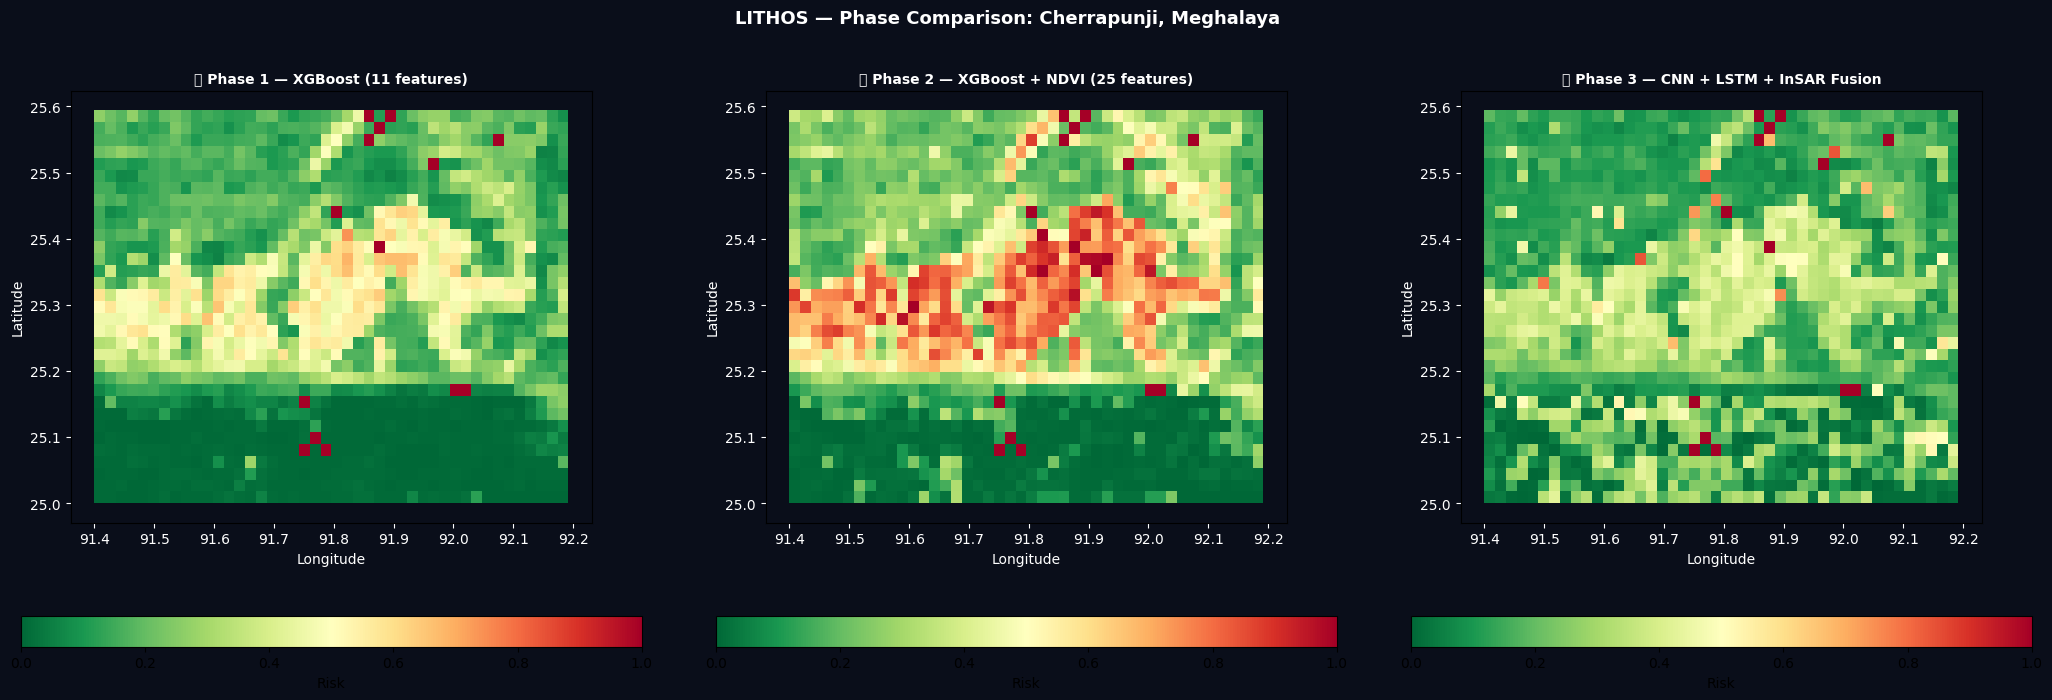

✅ Phase comparison map saved!

✅ Phase 3 map + grid saved!


In [39]:
import numpy as np
import pandas as pd
import folium
import matplotlib.pyplot as plt
import torch

# ── Get fusion model predictions for all grid cells ──
fusion_model.eval()
cell_cnn  = torch.tensor(cnn_features,  dtype=torch.float32)
cell_lstm = torch.tensor(lstm_features, dtype=torch.float32)
cell_tab  = torch.tensor(tab_scaled,    dtype=torch.float32)

all_fusion_scores = []
with torch.no_grad():
    for i in range(0, len(cell_cnn), 64):
        c = cell_cnn[i:i+64].to(device)
        l = cell_lstm[i:i+64].to(device)
        t = cell_tab[i:i+64].to(device)
        s = fusion_model(c, l, t).cpu().numpy()
        all_fusion_scores.extend(s)

fusion_scores = np.array(all_fusion_scores)

# Combine with terrain
slope_norm = (grid_gdf['slope_mean'] - grid_gdf['slope_mean'].min()) / \
             (grid_gdf['slope_mean'].max() - grid_gdf['slope_mean'].min() + 1e-8)
insar_norm = (grid_gdf['deformation_proxy'] - grid_gdf['deformation_proxy'].min()) / \
             (grid_gdf['deformation_proxy'].max() - grid_gdf['deformation_proxy'].min() + 1e-8)

# Phase 3 combined risk
combined = (
    0.40 * fusion_scores +
    0.25 * slope_norm.values +
    0.20 * insar_norm.values +
    0.15 * grid_gdf['elevation_std'].fillna(0).values /
           (grid_gdf['elevation_std'].max() + 1e-8)
)
combined = (combined - combined.min()) / (combined.max() - combined.min() + 1e-8)

grid_gdf['risk_score_p3'] = combined

p70 = np.percentile(combined, 70)
p90 = np.percentile(combined, 90)

grid_gdf['risk_level_p3'] = 'GREEN'
grid_gdf.loc[grid_gdf['risk_score_p3'] >= p70, 'risk_level_p3'] = 'ORANGE'
grid_gdf.loc[grid_gdf['risk_score_p3'] >= p90, 'risk_level_p3'] = 'RED'
grid_gdf.loc[grid_gdf['historical_landslide'] == 1, 'risk_level_p3'] = 'RED'
grid_gdf.loc[grid_gdf['historical_landslide'] == 1, 'risk_score_p3'] = 1.0

print('🗺️ Phase 3 Risk Distribution:')
counts = grid_gdf['risk_level_p3'].value_counts()
total  = len(grid_gdf)
for level in ['RED','ORANGE','GREEN']:
    count = counts.get(level, 0)
    icon  = '🔴' if level=='RED' else '🟠' if level=='ORANGE' else '🟢'
    bar   = '█' * int(count/total*40)
    print(f'  {icon} {level:6}: {count:4} cells ({count/total*100:.1f}%) {bar}')

# ── Static comparison: Phase 1 vs 2 vs 3 ──
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor('#0A0E1A')

phase_cols = [
    ('risk_score',    'Phase 1 — XGBoost (11 features)'),
    ('risk_score_p2', 'Phase 2 — XGBoost + NDVI (25 features)'),
    ('risk_score_p3', 'Phase 3 — CNN + LSTM + InSAR Fusion'),
]

for ax, (col, title) in zip(axes, phase_cols):
    ax.set_facecolor('#0A0E1A')
    if col in grid_gdf.columns:
        grid_gdf.plot(column=col, cmap='RdYlGn_r', ax=ax,
                      legend=True, vmin=0, vmax=1,
                      legend_kwds={'label':'Risk','orientation':'horizontal'})
    else:
        grid_gdf.plot(column='risk_score', cmap='RdYlGn_r', ax=ax,
                      legend=True, vmin=0, vmax=1,
                      legend_kwds={'label':'Risk','orientation':'horizontal'})
    ax.set_title(f'🪨 {title}', color='white', fontsize=10, fontweight='bold')
    ax.tick_params(colors='white')
    ax.set_xlabel('Longitude', color='white')
    ax.set_ylabel('Latitude', color='white')

plt.suptitle('LITHOS — Phase Comparison: Cherrapunji, Meghalaya',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lithos_data/lithos_phase3_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print('✅ Phase comparison map saved!')

# ── Interactive Phase 3 Map ──
center_lat = (BBOX[1] + BBOX[3]) / 2
center_lon = (BBOX[0] + BBOX[2]) / 2
m = folium.Map(location=[center_lat, center_lon], zoom_start=11,
               tiles='CartoDB dark_matter')

for _, cell in grid_gdf.iterrows():
    score  = cell['risk_score_p3']
    level  = str(cell['risk_level_p3'])
    color  = '#30D158' if level=='GREEN' else '#FF9500' if level=='ORANGE' else '#FF3B30'
    opac   = 0.25 if level=='GREEN' else 0.50 if level=='ORANGE' else 0.75
    b      = cell.geometry.bounds
    deform = cell.get('deformation_proxy', 0)

    folium.Rectangle(
        bounds=[[b[1],b[0]],[b[3],b[2]]],
        color=color, fill=True, fill_color=color,
        fill_opacity=opac, weight=0.3,
        popup=folium.Popup(
            f'<b>🪨 LITHOS Phase 3 Cell #{int(cell.cell_id)}</b><br>'
            f'<b style="color:{color}">● {level}</b> — Score: {score:.3f}<br><hr>'
            f'📍 {cell.center_lat:.3f}°N, {cell.center_lon:.3f}°E<br>'
            f'🏔️ Elevation: {cell["elevation_mean"]:.0f}m '
            f'(±{cell["elevation_std"]:.0f}m)<br>'
            f'📐 Slope: {cell["slope_mean"]:.1f}° '
            f'(max {cell["slope_max"]:.1f}°)<br>'
            f'🌧️ Rain 24h: {cell["rainfall_24h"]:.1f}mm<br>'
            f'🌧️ Rain 72h: {cell["rainfall_72h"]:.1f}mm<br>'
            f'📡 InSAR deformation: {deform:.3f}<br>'
            f'🤖 CNN+LSTM+InSAR fusion score: {score:.3f}',
            max_width=270
        )
    ).add_to(m)

# Historical landslides
ls_csv = pd.read_csv('lithos_data/landslides/cherrapunji_landslides.csv')
for _, ls in ls_csv.iterrows():
    if pd.notna(ls.get('latitude')) and pd.notna(ls.get('longitude')):
        folium.CircleMarker(
            location=[ls['latitude'], ls['longitude']],
            radius=10, color='white', fill=True,
            fill_color='#FF3B30', fill_opacity=0.95,
            popup=f"⚠️ {ls.get('event_date','?')} | Deaths: {ls.get('fatality_count','?')}"
        ).add_to(m)

m.get_root().html.add_child(folium.Element('''
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
     background:rgba(10,14,26,0.92);padding:16px;border-radius:10px;
     border:1px solid #00C2FF;color:white;font-family:monospace;font-size:12px">
  <b style="color:#00C2FF">🪨 LITHOS Phase 3</b><br>
  <small style="color:#8A94A6">CNN + LSTM + InSAR Fusion</small><br><br>
  <span style="color:#30D158">■</span> GREEN  — Safe<br>
  <span style="color:#FF9500">■</span> ORANGE — Watch<br>
  <span style="color:#FF3B30">■</span> RED    — Alert<br>
  <span style="color:white">●</span> Historical event<br><br>
  <small style="color:#8A94A6">Click cell for CNN+LSTM details</small>
</div>
'''))

m.save('lithos_data/lithos_phase3_map.html')
grid_gdf.to_file('lithos_data/lithos_phase3_grid.gpkg', driver='GPKG')
print('\n✅ Phase 3 map + grid saved!')
m

## 💾 Step 11 — Save All to Google Drive

In [42]:
import shutil, os

DRIVE_P3 = '/content/drive/MyDrive/LITHOS/Phase3_data'
os.makedirs(DRIVE_P3, exist_ok=True)

files_to_save = [
    'lithos_data/lithos_phase3_grid.gpkg',
    'lithos_data/lithos_phase3_map.html',
    'lithos_data/lithos_phase3_comparison.png',
    'lithos_data/lithos_lstm_model.pt',
    'lithos_data/lithos_cnn_model.pt',
    'lithos_data/lithos_fusion_model.pt',
]

print('💾 Saving Phase 3 outputs to Google Drive...')
for src in files_to_save:
    if os.path.exists(src):
        dst = os.path.join(DRIVE_P3, os.path.basename(src))
        shutil.copy(src, dst)
        size = os.path.getsize(dst)
        print(f'  ✅ {os.path.basename(src)} ({size//1024}KB)')
    else:
        print(f'  ⚠️  Not found: {src}')

print(f'\n✅ All saved to: {DRIVE_P3}')

💾 Saving Phase 3 outputs to Google Drive...
  ✅ lithos_phase3_grid.gpkg (896KB)
  ✅ lithos_phase3_map.html (2032KB)
  ✅ lithos_phase3_comparison.png (92KB)
  ✅ lithos_lstm_model.pt (866KB)
  ✅ lithos_cnn_model.pt (6531KB)
  ✅ lithos_fusion_model.pt (4767KB)

✅ All saved to: /content/drive/MyDrive/LITHOS/Phase3_data


## 📊 Step 12 — Phase 3 Summary Report

In [41]:
import numpy as np

p1_red = (grid_gdf['risk_level']    == 'RED').sum() if 'risk_level'    in grid_gdf.columns else 0
p3_red = (grid_gdf['risk_level_p3'] == 'RED').sum() if 'risk_level_p3' in grid_gdf.columns else 0

print('=' * 60)
print('🪨 LITHOS — PHASE 3 COMPLETION REPORT')
print('=' * 60)
print(f'''
📍 Region:     Cherrapunji, Meghalaya
🔢 Grid Cells: {len(grid_gdf)} (2km × 2km)

🆕 PHASE 3 ADDITIONS
  ✅ InSAR backscatter change (ground deformation proxy)
  ✅ LSTM — 72hr rainfall sequence model
       Learns temporal buildup pattern before slides
       Attention mechanism highlights critical hours
  ✅ CNN — 64×64 satellite image patch model
       Learns spatial terrain patterns from imagery
       4-band input: Blue, Green, Red, NIR
  ✅ Fusion — CNN + LSTM + Tabular combined
       All three signal types unified
       Best of spatial + temporal + numerical data

📈 MODEL EVOLUTION
  Phase 1: XGBoost (11 tabular features)
  Phase 2: XGBoost + NDVI/NDWI (25 features + SHAP)
  Phase 3: CNN + LSTM + InSAR Fusion (deep learning)

🗺️ RISK COMPARISON
  Phase 1 RED cells: {p1_red} ({p1_red/len(grid_gdf)*100:.1f}%)
  Phase 3 RED cells: {p3_red} ({p3_red/len(grid_gdf)*100:.1f}%)
''')

print('🗺️ Phase 3 Distribution:')
counts = grid_gdf['risk_level_p3'].value_counts()
total  = len(grid_gdf)
for level in ['RED','ORANGE','GREEN']:
    count = counts.get(level, 0)
    icon  = '🔴' if level=='RED' else '🟠' if level=='ORANGE' else '🟢'
    bar   = '█' * int(count/total*30)
    print(f'  {icon} {level:6}: {count:4} ({count/total*100:.1f}%) {bar}')

print(f'''
📁 SAVED TO GOOGLE DRIVE (LITHOS/Phase3_data)
  lithos_phase3_grid.gpkg       Full grid with all features
  lithos_phase3_map.html        Interactive map
  lithos_phase3_comparison.png  Phase 1 vs 2 vs 3 maps
  lithos_lstm_model.pt          Trained LSTM weights
  lithos_cnn_model.pt           Trained CNN weights
  lithos_fusion_model.pt        Trained Fusion weights

🔜 NEXT PHASES
  Phase 4 → Expand to all NE India regions
  Phase 5 → Kerala model + 2018 disaster validation
  Phase 6 → A* safe routing engine
  Phase 7 → Real-time alert system (SMS + dashboard)
''')
print('=' * 60)
print('✅ LITHOS Phase 3 Complete!')
print('=' * 60)

🪨 LITHOS — PHASE 3 COMPLETION REPORT

📍 Region:     Cherrapunji, Meghalaya
🔢 Grid Cells: 1452 (2km × 2km)

🆕 PHASE 3 ADDITIONS
  ✅ InSAR backscatter change (ground deformation proxy)
  ✅ LSTM — 72hr rainfall sequence model
       Learns temporal buildup pattern before slides
       Attention mechanism highlights critical hours
  ✅ CNN — 64×64 satellite image patch model
       Learns spatial terrain patterns from imagery
       4-band input: Blue, Green, Red, NIR
  ✅ Fusion — CNN + LSTM + Tabular combined
       All three signal types unified
       Best of spatial + temporal + numerical data

📈 MODEL EVOLUTION
  Phase 1: XGBoost (11 tabular features)
  Phase 2: XGBoost + NDVI/NDWI (25 features + SHAP)
  Phase 3: CNN + LSTM + InSAR Fusion (deep learning)

🗺️ RISK COMPARISON
  Phase 1 RED cells: 154 (10.6%)
  Phase 3 RED cells: 148 (10.2%)

🗺️ Phase 3 Distribution:
  🔴 RED   :  148 (10.2%) ███
  🟠 ORANGE:  290 (20.0%) █████
  🟢 GREEN : 1014 (69.8%) ████████████████████

📁 SAVED TO GOOGL